# Load Ernfors lab DRG integrated reference as rds and export for adata import

Reference: https://pubmed.ncbi.nlm.nih.gov/40500276/

The integrated dataset was provided by the authors.

**Pinned Environment:** [`envs/R_integration.yaml`](../../envs/R_integration.yaml)

In [1]:
packageVersion("Seurat")

[1] ‘5.3.0’

In [2]:
library(Seurat)
library(tidyverse)
library(jsonlite)

Loading required package: SeuratObject

Loading required package: sp


Attaching package: ‘SeuratObject’


The following objects are masked from ‘package:base’:

    intersect, t


── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.2
✔ ggplot2   3.5.2     ✔ tibble    3.3.0
✔ lubridate 1.9.4     ✔ tidyr     1.3.1
✔ purrr     1.1.0     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors

Attaching package: ‘jsonlite’


The following object is masked from ‘package:purrr’:

    flatten




In [3]:
# For plotting
library(ggplot2)
library(ggpmisc)
library(scales)
library(cowplot)
library(gridExtra)
library(viridis)
library(hrbrthemes)

Loading required package: ggpp

Registered S3 methods overwritten by 'ggpp':
  method                  from   
  heightDetails.titleGrob ggplot2
  widthDetails.titleGrob  ggplot2


Attaching package: ‘ggpp’


The following object is masked from ‘package:ggplot2’:

    annotate



Attaching package: ‘scales’


The following object is masked from ‘package:purrr’:

    discard


The following object is masked from ‘package:readr’:

    col_factor



Attaching package: ‘cowplot’


The following object is masked from ‘package:lubridate’:

    stamp



Attaching package: ‘gridExtra’


The following object is masked from ‘package:dplyr’:

    combine


Loading required package: viridisLite


Attaching package: ‘viridis’


The following object is masked from ‘package:scales’:

    viridis_pal




## File info

In [4]:
source("../../config/paths.R")

# Ernfors reference (external file - intentionally hardcoded)
ref_path <- file.path(DATA_DIR, "Ernfors_ref/mouse_drg_atlas.rds")

# Output directory
output_dir <- file.path(BASE_DIR, "figures/ernfors")
dir.create(output_dir, recursive = TRUE, showWarnings = FALSE)

## Load reference

In [5]:
ref <- readRDS(ref_path)

In [6]:
ref

An object of class Seurat 
38178 features across 44269 samples within 1 assay 
Active assay: RNA (38178 features, 2944 variable features)
 3 layers present: counts, data, scale.data
 3 dimensional reductions calculated: pca, harmony, umap

In [7]:
head(ref@meta.data)

,orig.ident,nCount_RNA,nFeature_RNA,dataset,celltype,sex,predicted_sex
,<chr>,<dbl>,<int>,<chr>,<fct>,<chr>,<chr>
10X91_1_AACACGTCAAGTTGTC-1,10X91_1,35326,6637,CD1,PEP1.2,Unknown,Male
10X91_1_AACCGCGCAAATACAG-1,10X91_1,20919,5273,CD1,C-LTMR,Unknown,Male
10X91_1_AACTCTTGTACACCGC-1,10X91_1,52236,7494,CD1,C-LTMR,Unknown,Male
10X91_1_AACTTTCGTAGCGTGA-1,10X91_1,40718,6698,CD1,PEP1.4,Unknown,Male
10X91_1_AAGACCTCACGCCAGT-1,10X91_1,43295,6968,CD1,PEP1.4,Unknown,Male
10X91_1_AAGCCGCCATCTGGTA-1,10X91_1,63743,7692,CD1,C-LTMR,Unknown,Male


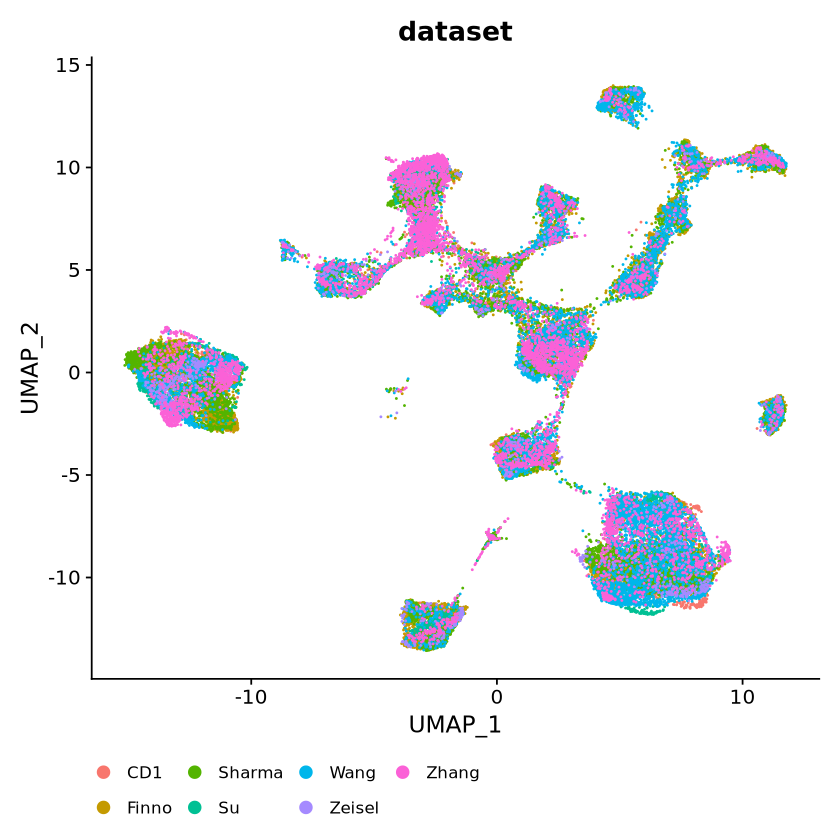

In [8]:
DimPlot(ref, reduction = "umap", 
              group.by = "dataset") +
  theme(
    legend.position = "bottom",       
    legend.text = element_text(size = 10),
    legend.key.size = unit(0.5, "cm")
  )

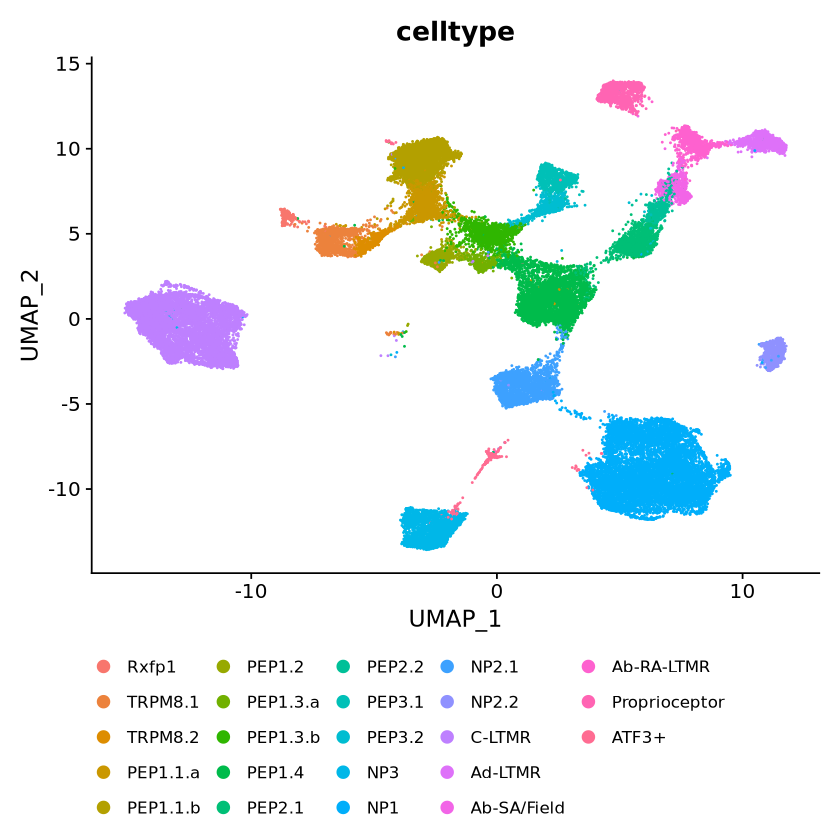

In [9]:
DimPlot(ref, reduction = "umap", 
              group.by = "celltype") +
  theme(
    legend.position = "bottom",       
    legend.text = element_text(size = 10),
    legend.key.size = unit(0.5, "cm")
  )

In [10]:
# check data layers
counts <- ref[["RNA"]]$counts
data <- ref[["RNA"]]$data
scale.data <- ref[["RNA"]]$scale.data

In [11]:
print(dim(counts))
print(dim(data))
print(dim(scale.data))

[1] 38178 44269
[1] 38178 44269
[1]  3658 44269


In [12]:
head(counts)

  [[ suppressing 34 column names ‘10X91_1_AACACGTCAAGTTGTC-1’, ‘10X91_1_AACCGCGCAAATACAG-1’, ‘10X91_1_AACTCTTGTACACCGC-1’ ... ]]



6 x 44269 sparse Matrix of class "dgCMatrix"
                                                                           
Xkr4    . 1 . . . . . . . . . . . . . . . 1 . . . . . . 1 . . . . . . . . .
Gm1992  . . . . . . . . . . . . . . . . . . . . . . . . . . . . . 1 . . . .
Gm37381 . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . .
Rp1     . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . .
Sox17   . . 1 . . . . . . . 1 . . . . . . . . . . . . . . . . . . . . . . .
Gm37323 . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . .
              
Xkr4    ......
Gm1992  ......
Gm37381 ......
Rp1     ......
Sox17   ......
Gm37323 ......

 .....suppressing 44235 columns in show(); maybe adjust options(max.print=, width=)
 ..............................

In [13]:
head(data)

  [[ suppressing 34 column names ‘10X91_1_AACACGTCAAGTTGTC-1’, ‘10X91_1_AACCGCGCAAATACAG-1’, ‘10X91_1_AACTCTTGTACACCGC-1’ ... ]]



6 x 44269 sparse Matrix of class "dgCMatrix"
                                                                              
Xkr4    . 0.390713 .         . . . . . . . .         . . . . . . 0.1527072 . .
Gm1992  . .        .         . . . . . . . .         . . . . . . .         . .
Gm37381 . .        .         . . . . . . . .         . . . . . . .         . .
Rp1     . .        .         . . . . . . . .         . . . . . . .         . .
Sox17   . .        0.1751617 . . . . . . . 0.1414304 . . . . . . .         . .
Gm37323 . .        .         . . . . . . . .         . . . . . . .         . .
                                                           
Xkr4    . . . . 0.09579537 . . . . .         . . . . ......
Gm1992  . . . . .          . . . . 0.1292151 . . . . ......
Gm37381 . . . . .          . . . . .         . . . . ......
Rp1     . . . . .          . . . . .         . . . . ......
Sox17   . . . . .          . . . . .         . . . . ......
Gm37323 . . . . .          . . . . .      

In [14]:
head(scale.data)

,10X91_1_AACACGTCAAGTTGTC-1,10X91_1_AACCGCGCAAATACAG-1,10X91_1_AACTCTTGTACACCGC-1,10X91_1_AACTTTCGTAGCGTGA-1,10X91_1_AAGACCTCACGCCAGT-1,10X91_1_AAGCCGCCATCTGGTA-1,10X91_1_ACACCAACACAACGTT-1,10X91_1_ACACCCTTCAAACCGT-1,10X91_1_ACAGCTAGTACAGTGG-1,10X91_1_ACCGTAACACATTAGC-1,⋯,GSM6656593_TTTGGTTAGAGTATAC-1,GSM6656593_TTTGGTTAGATACAGT-1,GSM6656593_TTTGGTTAGTATGACA-1,GSM6656593_TTTGGTTGTCTACAGT-1,GSM6656593_TTTGGTTGTGGCTCTG-1,GSM6656593_TTTGGTTTCCATTGTT-1,GSM6656593_TTTGGTTTCTATCGCC-1,GSM6656593_TTTGTTGGTCGTAATC-1,GSM6656593_TTTGTTGGTGGACCAA-1,GSM6656593_TTTGTTGTCCCGTGTT-1
Rgs20,-0.19161198,-0.19161198,0.96203589,-0.19161198,1.17703320,-0.19161198,-0.19161198,0.91333707,-0.19161198,-0.19161198,⋯,-0.19161198,-0.19161198,-0.19161198,-0.19161198,-0.19161198,-0.19161198,-0.19161198,-0.19161198,-0.19161198,-0.19161198
Oprk1,-0.15743459,-0.15743459,-0.15743459,-0.15743459,-0.15743459,-0.15743459,-0.15743459,-0.15743459,-0.15743459,-0.15743459,⋯,-0.15743459,-0.15743459,-0.15743459,-0.15743459,-0.15743459,-0.15743459,-0.15743459,-0.15743459,-0.15743459,-0.15743459
Rb1cc1,0.88011662,-1.05781309,0.89774975,0.50607679,0.82013393,-1.05781309,0.31606700,0.20884944,0.61389191,0.89604871,⋯,0.39859135,1.48109025,1.11716674,1.59406411,-0.38795348,1.16267792,1.09901270,0.43367881,0.14252851,1.57317893
St18,-0.03700157,-0.03700157,-0.03700157,-0.03700157,-0.03700157,-0.03700157,-0.03700157,-0.03700157,-0.03700157,-0.03700157,⋯,-0.03700157,-0.03700157,-0.03700157,-0.03700157,-0.03700157,-0.03700157,-0.03700157,-0.03700157,-0.03700157,-0.03700157
Tcf24,-0.03395883,-0.03395883,-0.03395883,-0.03395883,-0.03395883,-0.03395883,-0.03395883,-0.03395883,-0.03395883,-0.03395883,⋯,-0.03395883,-0.03395883,-0.03395883,-0.03395883,-0.03395883,-0.03395883,-0.03395883,-0.03395883,-0.03395883,-0.03395883
Cops5,1.62980209,-1.01041195,0.30965228,0.56436919,0.02449848,1.27385812,0.67902796,-0.39827596,0.15886142,0.69121792,⋯,0.07737052,0.87000807,0.08328445,0.13209866,1.42746638,0.03990386,0.15319572,-0.20066071,0.94125912,0.59767161


## Export Seurat object for loading to AnnData

In [15]:
# save metadata separately
meta_df <- ref@meta.data
write.csv(meta_df, file = file.path(output_dir, "cell_metadata.csv"))

### Convert to AnnData

In [1]:
library(anndata)

In [16]:
# 1. Get the full gene list from the main assay
all_genes <- rownames(ref)
scaled_genes <- rownames(GetAssayData(ref, layer = "scale.data"))

# 2. Create a "full-sized" scale.data matrix filled with 0s
# This ensures dimensions match 
full_scale_mat <- matrix(0, nrow = length(all_genes), ncol = ncol(ref))
rownames(full_scale_mat) <- all_genes
colnames(full_scale_mat) <- colnames(ref)

# 3. Fill in the values we actually have
full_scale_mat[scaled_genes, ] <- GetAssayData(ref, layer = "scale.data")

# 4. Create AnnData
adata_obj <- AnnData(
  X = t(GetAssayData(ref, layer = "data")), # Full log-norm
  layers = list(
    counts = t(GetAssayData(ref, layer = "counts")),
    scale_data = t(full_scale_mat) # Now matches dimensions
  ),
  obs = ref@meta.data,
  obsm = list(
    X_pca = Embeddings(ref, "pca"),
    X_umap = Embeddings(ref, "umap")
  )
)

# save
adata_obj$write_h5ad(file.path(output_dir, "ernfors_ref_complete.h5ad"))

In [2]:
# library(reticulate)
# py_config()